In [14]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

In [15]:
home = Path.home()
data_path = home / 'Programming/data/fraud-detection/data'
work_dir = home / (
    'Programming/Python/machine-learning-exercises/credit-card-fraud-detection'
    )
data_df = pd.read_csv(
    data_path / 'transactions_obf.csv', parse_dates=['transactionTime'],
    dtype={'availableCash': np.float64, 'transactionAmount': np.float64}
    )
data_df.sort_values(by='transactionTime', inplace=True)

In [16]:
# matplotlib style file
mplstyle_file = work_dir / 'barplot-style.mplstyle'
plt.style.use(mplstyle_file)

In [17]:
data_df[['eventId', 'accountNumber', 'merchantId', 'mcc', 'merchantCountry', 'merchantZip', 'posEntryMode']] = data_df[['eventId', 'accountNumber', 'merchantId', 'mcc', 'merchantCountry', 'merchantZip', 'posEntryMode']].astype('string')

In [18]:
labels_df = pd.read_csv(data_path / 'labels_obf.csv', parse_dates=['reportedTime'])
labels_df.sort_values(by='reportedTime', inplace=True)
data_df['fraudCase'] = data_df.eventId.isin(labels_df.eventId).astype(int)

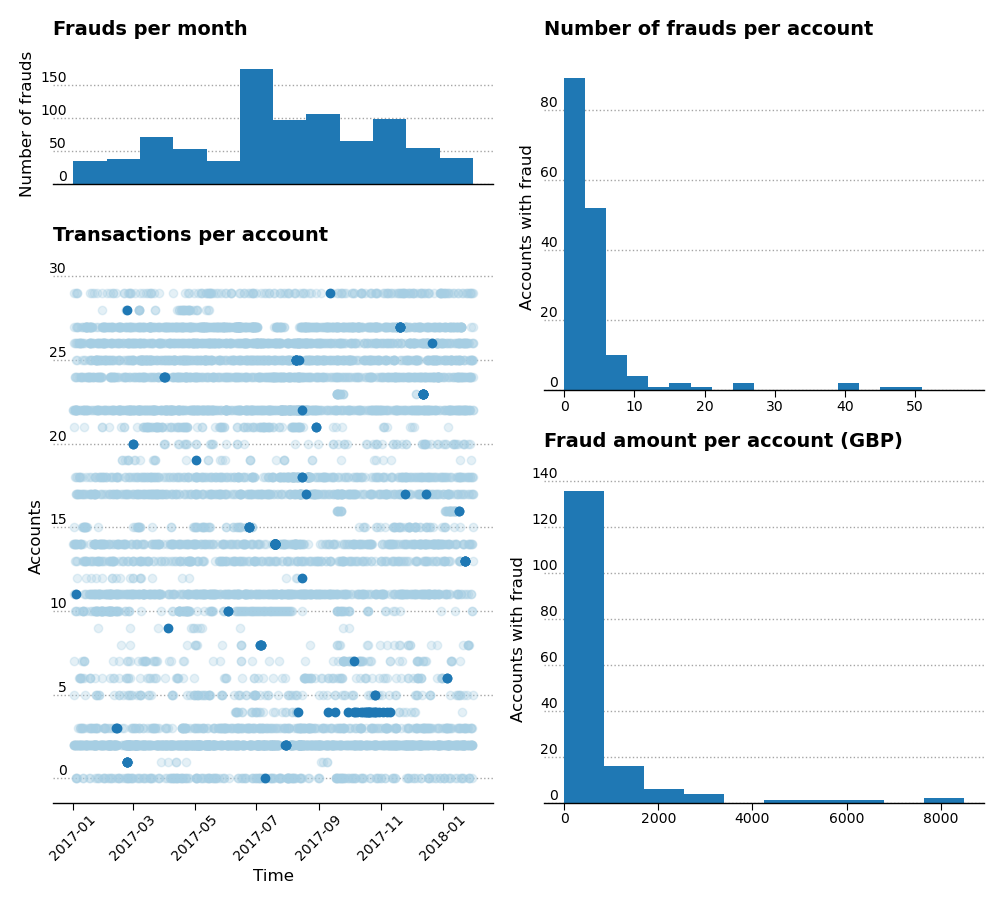

In [19]:
mpl.rc('axes', labelsize=12)

fig, axes = plt.subplot_mosaic([['1.', '3.'], 
                               ['2.', '3.'], 
                               ['2.', '4.'],
                               ['2.', '4.']],
                               figsize=(10,9))

# transactions per account
plt.axes(axes['2.'])
acc_with_frauds = sorted(data_df['accountNumber'].loc[data_df['fraudCase']==1].unique().tolist())
cmap=plt.cm.Paired.colors

for i in range(30):
    acc = acc_with_frauds[i]
    fraud = data_df['fraudCase'].loc[data_df['accountNumber']==acc]
    xx = data_df['transactionTime'].loc[data_df['accountNumber']==acc]
    plt.scatter(xx, np.ones(len(xx))*i, marker='o', color=cmap[0], alpha=0.3)
    plt.scatter(xx[fraud==1], np.ones(len(xx[fraud==1]))*i, color=cmap[1])

plt.xticks(rotation=45)
plt.xlabel('Time')
plt.ylabel('Accounts')
plt.title('Transactions per account')


# frauds per month
plt.axes(axes['1.'])
plt.hist(data_df['transactionTime'].loc[data_df['fraudCase']==1], bins=12, color=cmap[1])
plt.xticks([])
plt.ylabel('Number of frauds')
plt.title('Frauds per month')


# number of frauds per account
label_encoder = LabelEncoder()
data_df.accountNumber = label_encoder.fit_transform(data_df.accountNumber)

num_fraud_per_account = []
for acc in range(max(data_df['accountNumber'])):
    num_fraud_per_account.append(
        np.sum(data_df['fraudCase'].loc[data_df['accountNumber']==acc])
        )
num_fraud_per_account = np.array([num_fraud_per_account])
tm = num_fraud_per_account[np.where(num_fraud_per_account>0)]

plt.axes(axes['3.'])
plt.hist(tm, bins=np.arange(0, 60, 3), color=cmap[1])
plt.title('Number of frauds per account')
plt.ylabel('Accounts with fraud')


# fraud amount per account
fraud_df = data_df[data_df.fraudCase == 1]
fraud_amount_per_account = fraud_df.groupby('accountNumber')['transactionAmount'].sum()

plt.axes(axes['4.'])
plt.hist(fraud_amount_per_account, color=cmap[1])
plt.title('Fraud amount per account (GBP)')
plt.ylabel('Accounts with fraud')

plt.tight_layout()


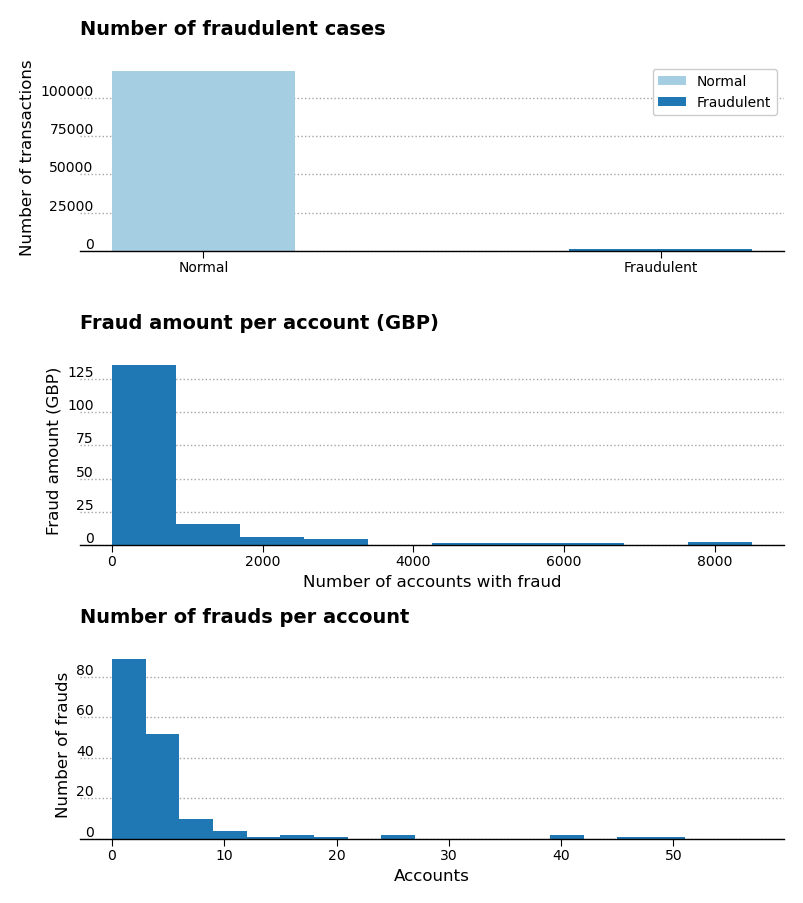

In [20]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 9))
ax1.bar([0, 1], [(data_df.fraudCase == 0).sum(), (data_df.fraudCase == 1).sum()],
       width=0.4, color=plt.cm.Paired.colors, label=['Normal', 'Fraudulent'])
ax1.set_xticks([0, 1], ['Normal', 'Fraudulent'])
ax1.set_ylabel('Number of transactions')
ax1.set_title('Number of fraudulent cases')
ax1.legend(loc='upper right')

fraud_df = data_df[data_df.fraudCase == 1]
fraud_amount_per_account = fraud_df.groupby('accountNumber')['transactionAmount'].sum()
ax2.hist(fraud_amount_per_account, color=plt.cm.Paired.colors[1])
ax2.set_title('Fraud amount per account (GBP)')
ax2.set_xlabel('Number of accounts with fraud')
ax2.set_ylabel('Fraud amount (GBP)')

number_of_frauds_per_account = [] 
unique_accounts_with_fraud = list(fraud_df.accountNumber.unique())
for account in unique_accounts_with_fraud:
    number_of_frauds_per_account.append(
        np.sum(fraud_df.accountNumber == account)
    )
ax3.hist(number_of_frauds_per_account, bins=np.arange(0, 60, 3))
ax3.set_title('Number of frauds per account')
ax3.set_xlabel('Accounts')
ax3.set_ylabel('Number of frauds')

plt.tight_layout()


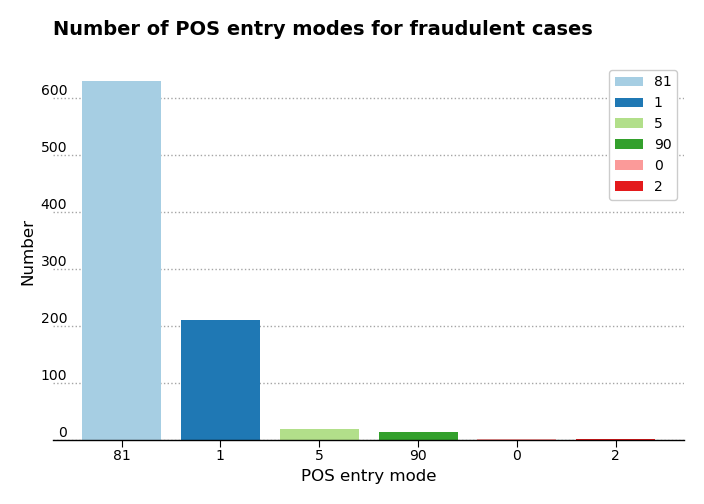

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
fraud_df = data_df[data_df.fraudCase == 1]
pos_fraud_df = fraud_df.posEntryMode.value_counts(ascending=False)
ax.bar(pos_fraud_df.index, pos_fraud_df.values,
       label=pos_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('POS entry mode')
ax.set_ylabel('Number')
ax.set_title('Number of POS entry modes for fraudulent cases')
plt.legend()
plt.tight_layout()

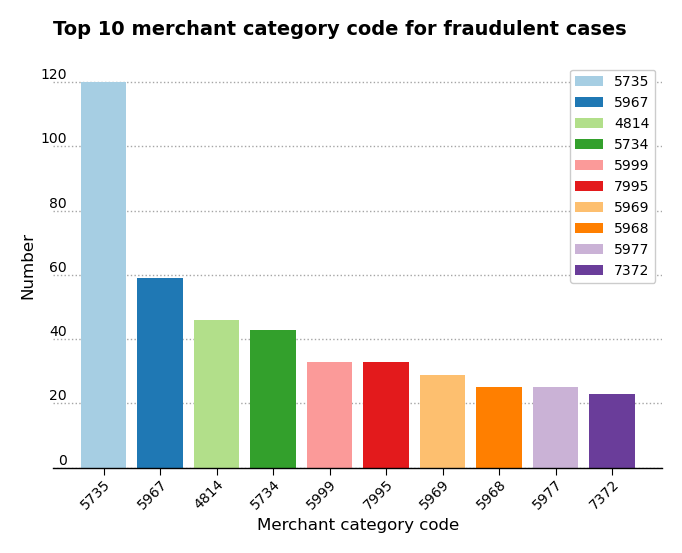

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
mcc_fraud_df = fraud_df.mcc.value_counts(ascending=False)[:top_num]
ax.bar(mcc_fraud_df.index, mcc_fraud_df.values,
       label=mcc_fraud_df.index,
       color=plt.cm.Paired.colors)
plt.setp(ax.get_xticklabels(), rotation_mode='anchor', rotation=45, ha='right')
ax.set_xlabel('Merchant category code')
ax.set_ylabel('Number')
ax.set_title(f'Top {top_num} merchant category code for fraudulent cases')
plt.legend();

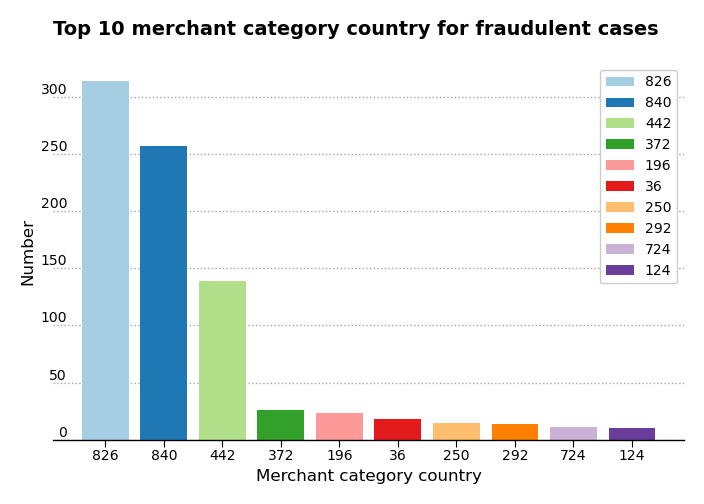

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
mctry_fraud_df = fraud_df.merchantCountry.value_counts(ascending=False)[:top_num]
ax.bar(mctry_fraud_df.index, mctry_fraud_df.values,
       label=mctry_fraud_df.index, color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant category country')
ax.set_ylabel('Number')
ax.set_title(f'Top {top_num} merchant category country for fraudulent cases')
plt.legend()
plt.tight_layout()

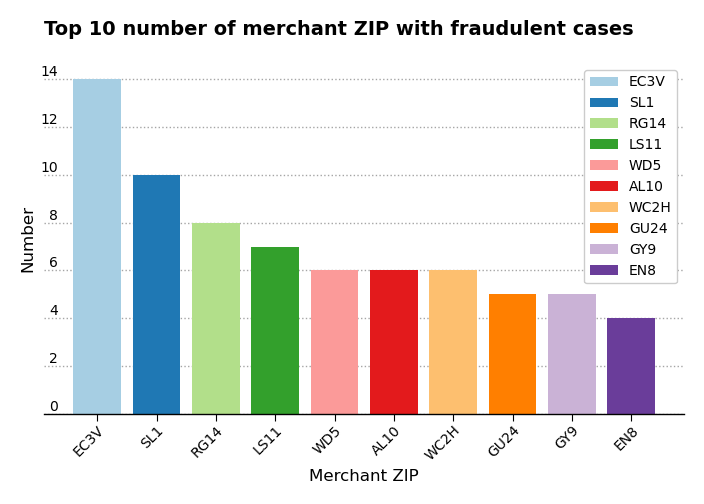

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
mod_fraud_df = fraud_df.loc[fraud_df.merchantZip != '0']
mz_fraud_df = mod_fraud_df.merchantZip.value_counts(ascending=False)[:top_num]
ax.bar(mz_fraud_df.index, mz_fraud_df.values, label=mz_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant ZIP')
ax.set_ylabel('Number')
ax.set_title(f'Top {top_num} number of merchant ZIP with fraudulent cases')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.legend()
plt.tight_layout()

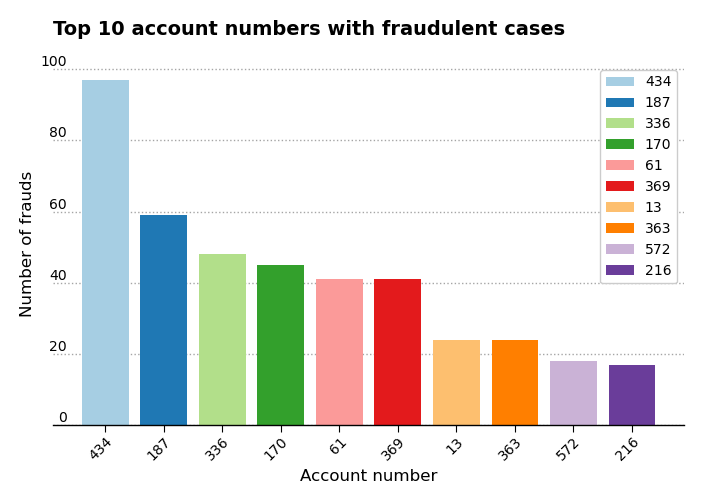

In [41]:
fig, ax = plt.subplots(figsize=(7, 5))
top_num = 10
an_fraud_df = fraud_df.groupby('accountNumber')['accountNumber'].count()
sorted_an_fraud_df = an_fraud_df.nlargest(top_num)
sorted_index = sorted_an_fraud_df.index.astype('str')
ax.bar(sorted_index, sorted_an_fraud_df.values,
       label=sorted_an_fraud_df.index, color=plt.cm.Paired.colors)
ax.set_xlabel('Account number')
ax.set_ylabel('Number of frauds')
ax.set_title(f'Top {top_num} account numbers with fraudulent cases')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.legend()
plt.tight_layout()
